## Importe

In diesem Abschnitt werden die notwendigen Bibliotheken importiert, die für die Datenanalyse und Visualisierung verwendet werden.

In [24]:
import pandas as pd
import numpy as np
from IPython.display import display
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils import resample

## Einlesen der CSV-Dateien

In diesem Abschnitt werden die CSV-Dateien eingelesen, die die Gesundheitsindikatoren und Diabetes-Daten enthalten. Diese Daten werden in Pandas DataFrames geladen, um sie für die Analyse und Visualisierung vorzubereiten.

Die folgenden CSV-Dateien werden eingelesen:
- `diabetes_012_health_indicators_BRFSS2015.csv`: Enthält Daten zu verschiedenen Gesundheitsindikatoren und dem Diabetes-Status (0, 1 oder 2).
- `diabetes_binary_health_indicators_BRFSS2015.csv`: Enthält Daten zu verschiedenen Gesundheitsindikatoren und einem binären Diabetes-Status (0 oder 1).
- `diabetes_binary_5050split_health_indicators_BRFSS2015.csv`: Enthält Daten zu verschiedenen Gesundheitsindikatoren und einem binären Diabetes-Status (0 oder 1), wobei die Daten gleichmäßig aufgeteilt sind.

Im weiteren Verlauf des Codes wird nur die `diabetes_012_health_indicators_BRFSS2015.csv` genutzt, da dies der Grunddatensatz ist und die anderen zwei CSV Datein auf diesen aufbauen und die gleichen Daten enthalten.


In [25]:
df_diabetes_012 = pd.read_csv('dataset/diabetes_012_health_indicators_BRFSS2015.csv')
df_diabetes_binary = pd.read_csv('dataset/diabetes_binary_health_indicators_BRFSS2015.csv')
df_diabetes_binary_50_50 = pd.read_csv('dataset/diabetes_binary_5050split_health_indicators_BRFSS2015.csv')

## Form des Datensatzes `df_diabetes_binary_50_50`

In diesem Abschnitt wird die Form des Datensatzes `df_diabetes_binary_50_50` dargestellt. Die Form eines DataFrames gibt die Anzahl der Zeilen und Spalten an und ist ein wichtiger erster Schritt, um ein Gefühl für die Größe und Struktur der Daten zu bekommen.

Die Form des Datensatzes `df_diabetes_binary_50_50` ist wie folgt:

In [26]:
print(f"Shape df_diabetes_binary_50_50: {df_diabetes_binary_50_50.shape}")

Shape df_diabetes_binary_50_50: (70692, 22)


## Spalten der Datensätze

In diesem Abschnitt werden die Spaltennamen der eingelesenen Datensätze angezeigt. Dies gibt einen Überblick über die verschiedenen Gesundheitsindikatoren und Merkmale, die in den Datensätzen enthalten sind.

### Spaltennamen für alle CSV Dateien mit Skalenniveau und Typ

- **Diabetes_012**: Diabetes-Status (0, 1 oder 2), Ordinal, Output
- **HighBP**: Bluthochdruck (0 oder 1), Nominal (binär), Input
- **HighChol**: Hoher Cholesterinspiegel (0 oder 1), Nominal (binär), Input
- **CholCheck**: Cholesterinüberprüfung (0 oder 1), Nominal (binär), Input
- **BMI**: Body-Mass-Index, Kardinal, Input
- **Smoker**: Raucherstatus (0 oder 1), Nominal (binär), Input
- **Stroke**: Schlaganfall (0 oder 1), Nominal (binär), Input
- **HeartDiseaseorAttack**: Herzkrankheit oder Herzinfarkt (0 oder 1), Nominal (binär), Input
- **PhysActivity**: Körperliche Aktivität (0 oder 1), Nominal (binär), Input
- **Fruits**: Obstkonsum (0 oder 1), Nominal (binär), Input
- **Veggies**: Gemüsekonsum (0 oder 1), Nominal (binär), Input
- **HvyAlcoholConsump**: Hoher Alkoholkonsum (0 oder 1), Nominal (binär), Input
- **AnyHealthcare**: Zugang zu Gesundheitsversorgung (0 oder 1), Nominal (binär), Input
- **NoDocbcCost**: Kein Arztbesuch wegen Kosten (0 oder 1), Nominal (binär), Input
- **genhlth**: allgemeiner gesundheitszustand (1 bis 5), Ordinal, Input
- **menthlth**: mentale gesundheit (anzahl der tage), Kardinal, Input
- **physhlth**: körperliche gesundheit (anzahl der tage), Kardinal, Input
- **diffwalk**: schwierigkeiten beim gehen (0 oder 1), Nominal (binär), Input
- **sex**: geschlecht (0 oder 1), Nominal (binär), Input
- **age**: alter (in jahren)Ordinal, Input
- **education**: bildungsstand (1 bis 6)Ordinal, Input
- **income**: einkommen (1 bis 8)Ordinal, Input


In [27]:
# TODO Spalten genauer Beschreiben
print(f"Columns df_diabetes_binary_50_50: {df_diabetes_binary_50_50.columns}")

Columns df_diabetes_binary_50_50: Index(['Diabetes_binary', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker',
       'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education',
       'Income'],
      dtype='object')


## Statistische Beschreibung der Datensätze

In diesem Abschnitt wird die statistische Beschreibung des Datensatzes `df_diabetes_binary_50_50` dargestellt. Diese Beschreibung umfasst Kennzahlen wie Mittelwert, Standardabweichung, Minimum, Maximum und Perzentile für jede Spalte der Datensätze.

### Statistische Beschreibung für `df_diabetes_binary_50_50`

Die statistische Beschreibung des Datensatzes `df_diabetes_binary_50_50` zeigt die Verteilung der verschiedenen Gesundheitsindikatoren und Merkmale:

In [28]:
display(df_diabetes_binary_50_50.describe().T)

,count,mean,std,min,25%,50%,75%,max
Diabetes_binary,70692.0,0.500000,0.500004,0.0,0.0,0.5,1.0,1.0
HighBP,70692.0,0.563458,0.495960,0.0,0.0,1.0,1.0,1.0
HighChol,70692.0,0.525703,0.499342,0.0,0.0,1.0,1.0,1.0
CholCheck,70692.0,0.975259,0.155336,0.0,1.0,1.0,1.0,1.0
BMI,70692.0,29.856985,7.113954,12.0,25.0,29.0,33.0,98.0
Smoker,70692.0,0.475273,0.499392,0.0,0.0,0.0,1.0,1.0
Stroke,70692.0,0.062171,0.241468,0.0,0.0,0.0,0.0,1.0
HeartDiseaseorAttack,70692.0,0.147810,0.354914,0.0,0.0,0.0,0.0,1.0
PhysActivity,70692.0,0.703036,0.456924,0.0,0.0,1.0,1.0,1.0
Fruits,70692.0,0.611795,0.487345,0.0,0.0,1.0,1.0,1.0


## Korrelationsmatrix

Die Korrelationsmatrix zeigt die Korrelationen zwischen verschiedenen Gesundheitsindikatoren im Datensatz `df_diabetes_binary_50_50`. Eine Korrelation gibt an, wie stark zwei Variablen miteinander zusammenhängen. Die Werte reichen von -1 bis 1, wobei -1 eine perfekte negative Korrelation, 0 keine Korrelation und 1 eine perfekte positive Korrelation darstellt.

### Visualisierung der Korrelationsmatrix

Um die Korrelationen besser zu verstehen, haben wir eine Heatmap der Korrelationsmatrix erstellt. In dieser Heatmap sind die Korrelationen farblich dargestellt, wobei stärkere Korrelationen durch intensivere Farben hervorgehoben werden.

### Interpretation der Korrelationsmatrix

Einige wichtige Beobachtungen aus der Korrelationsmatrix sind:

- **Diabetes_012** zeigt eine moderate positive Korrelation mit **GenHlth** (0.30) und **Age** (0.19).
- **HighBP** (Bluthochdruck) korreliert stark mit **Age** (0.34) und **GenHlth** (0.30).
- **PhysActivity** (körperliche Aktivität) zeigt eine moderate negative Korrelation mit **GenHlth** (-0.27) und **DiffWalk** (-0.25).

Diese Korrelationen können Hinweise auf mögliche Zusammenhänge zwischen verschiedenen Gesundheitsindikatoren und Diabetes liefern und helfen, weitere Analysen und Hypothesen zu entwickeln.

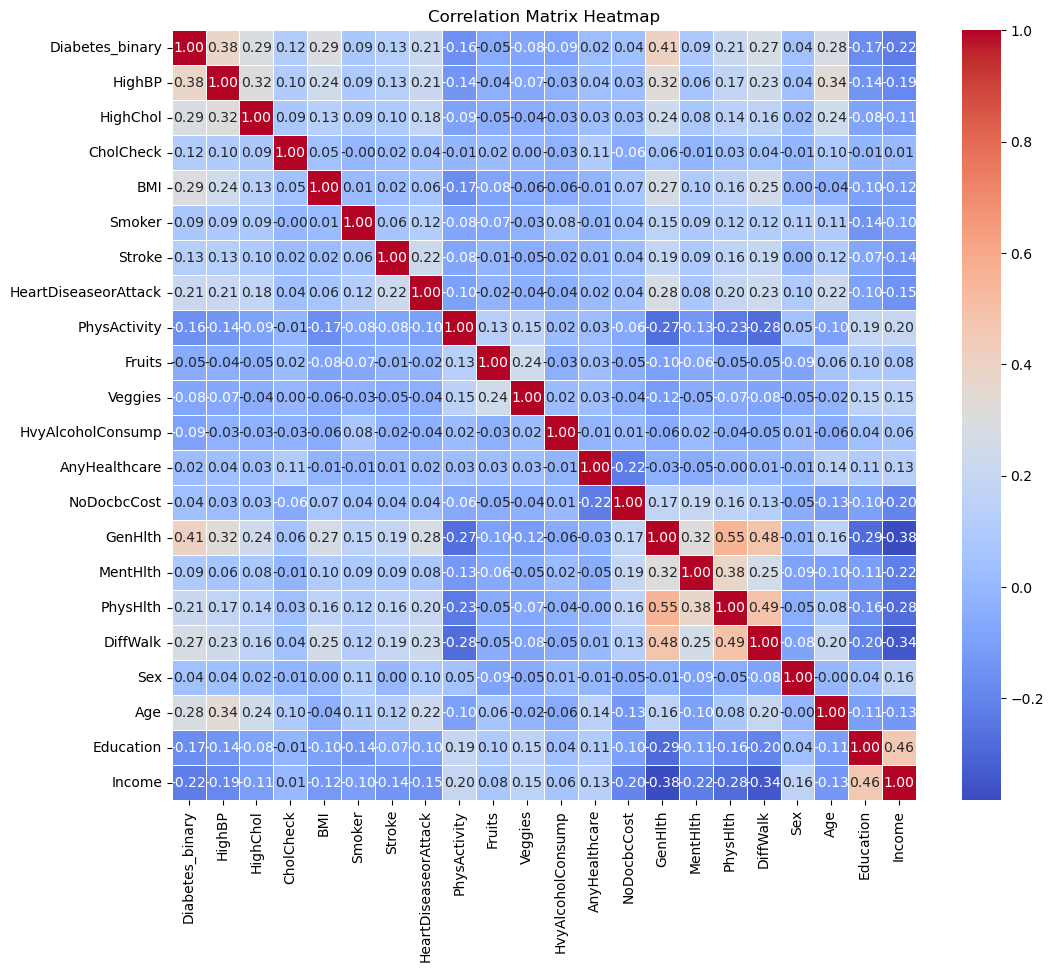

In [38]:
correlation_matrix = df_diabetes_binary_50_50.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=.5)
plt.title('Correlation Matrix Heatmap')
plt.show()

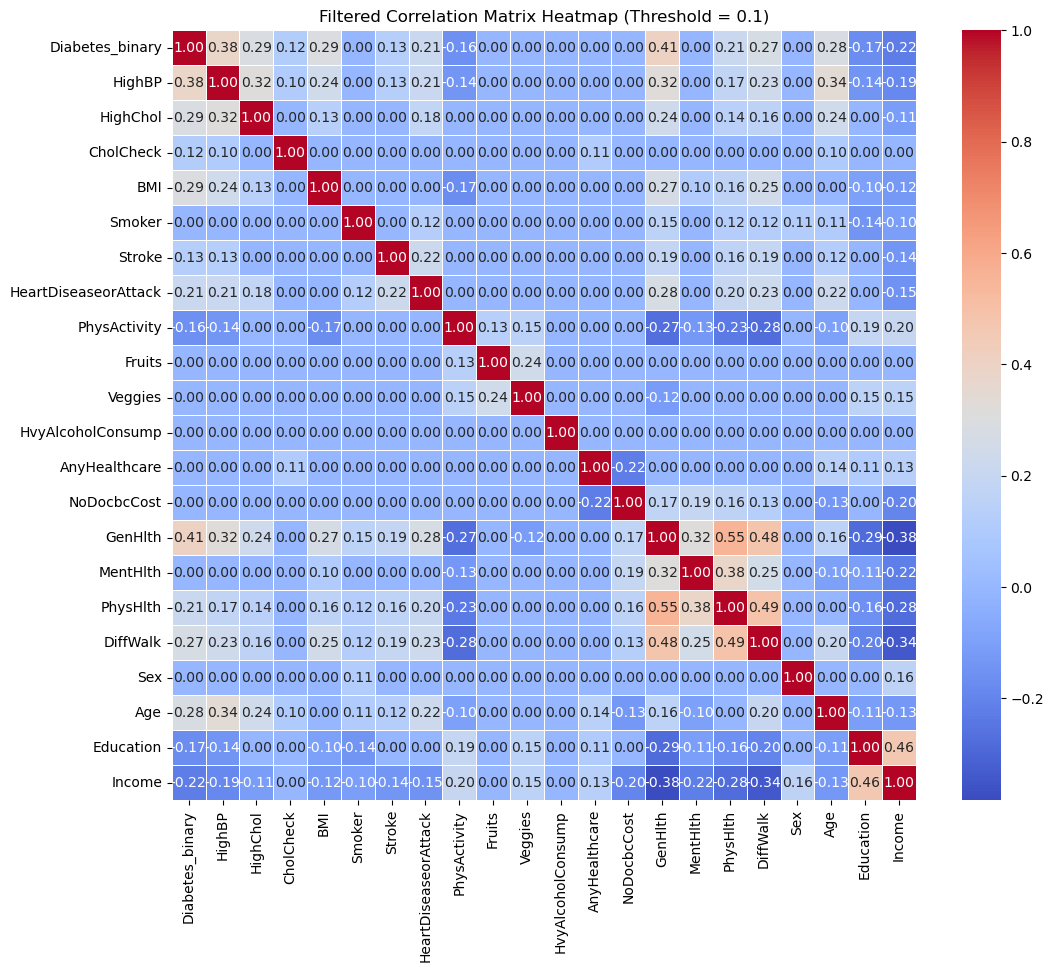

In [33]:
# Set the threshold
threshold = 0.1

# Filter the correlation matrix
filtered_correlation_matrix = correlation_matrix.copy()
filtered_correlation_matrix[abs(filtered_correlation_matrix) < threshold] = 0

# Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(filtered_correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=.5)
plt.title('Filtered Correlation Matrix Heatmap (Threshold = 0.1)')
plt.show()

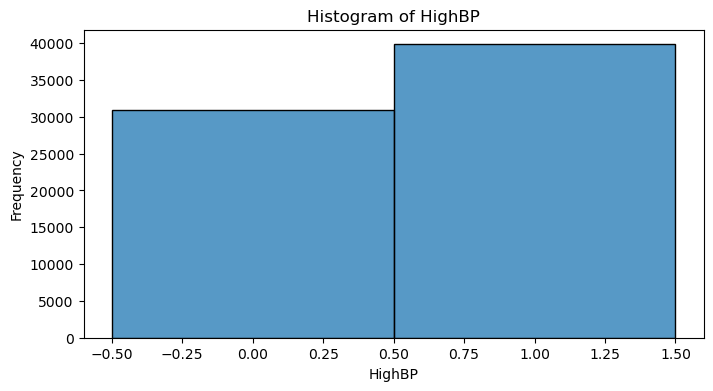

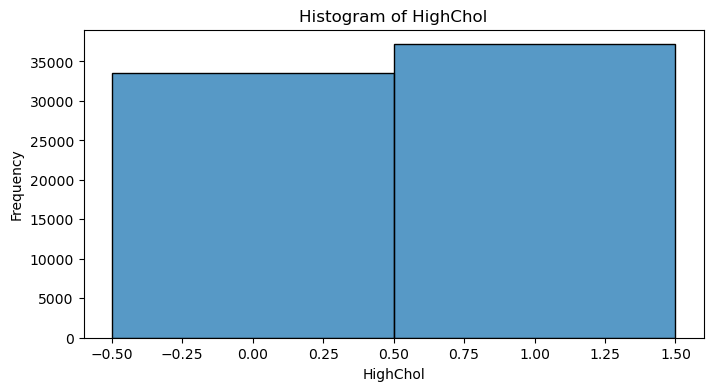

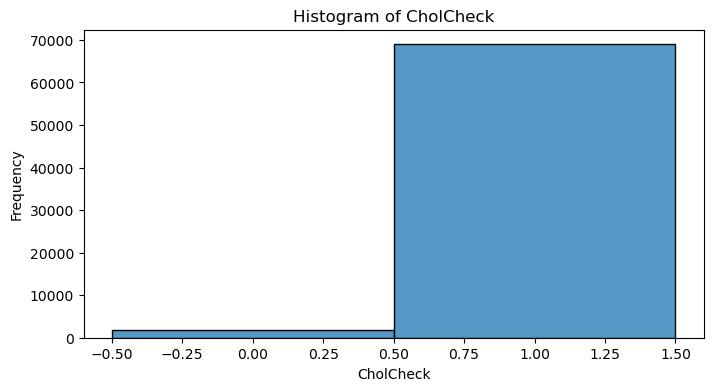

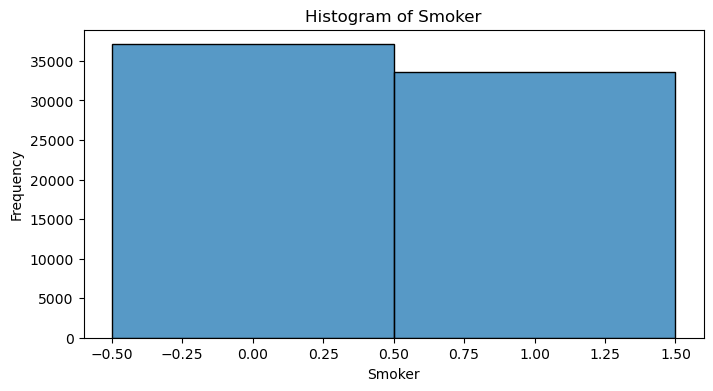

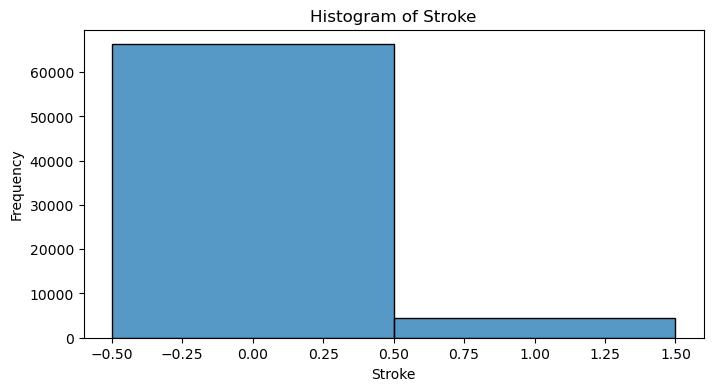

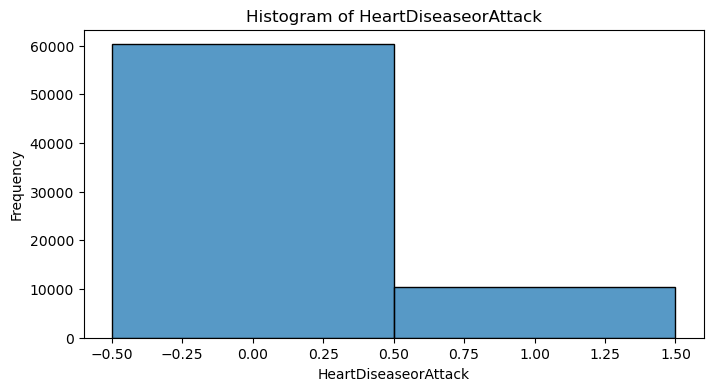

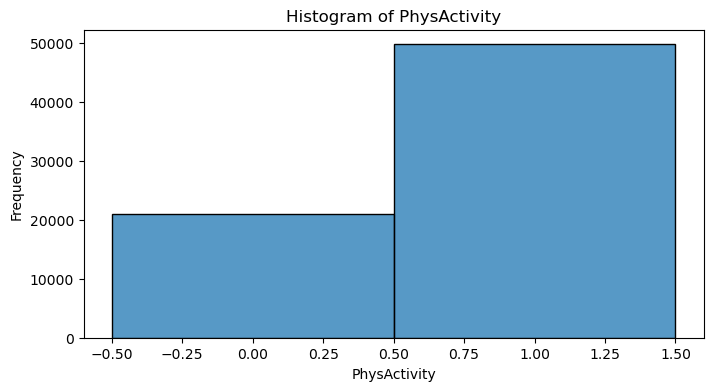

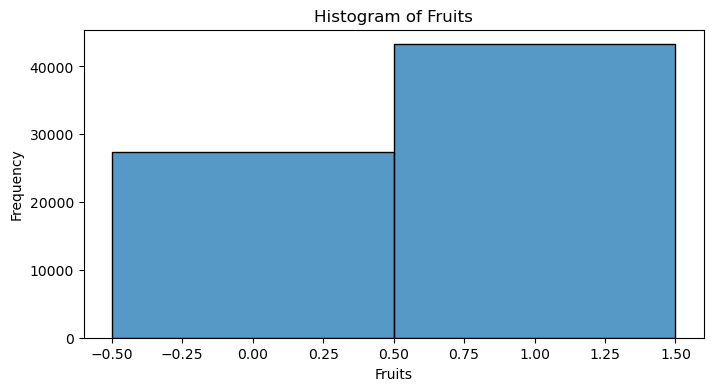

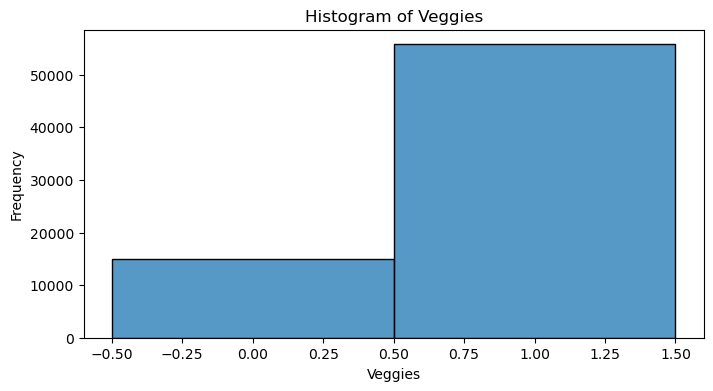

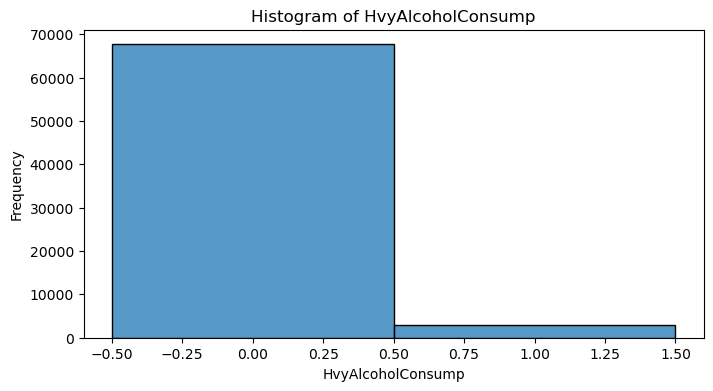

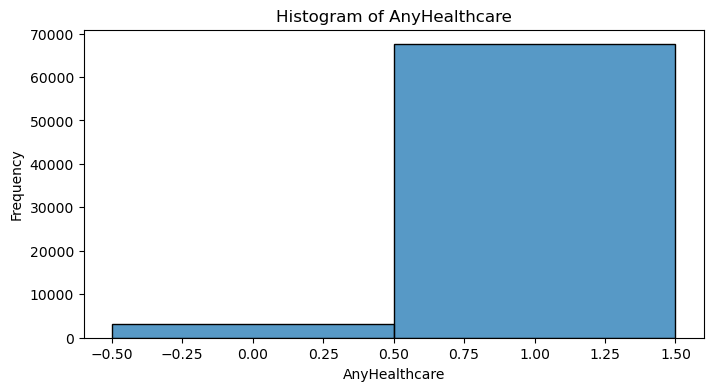

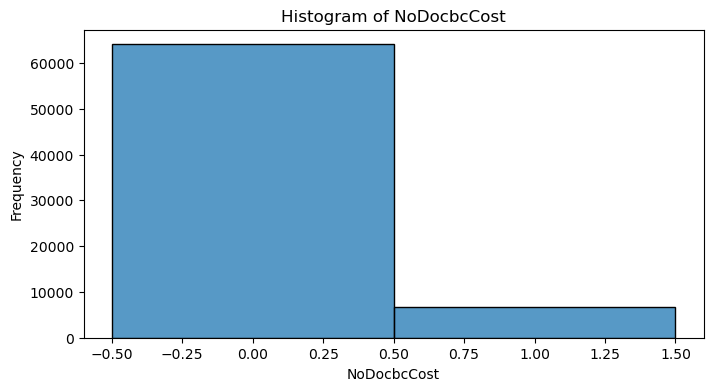

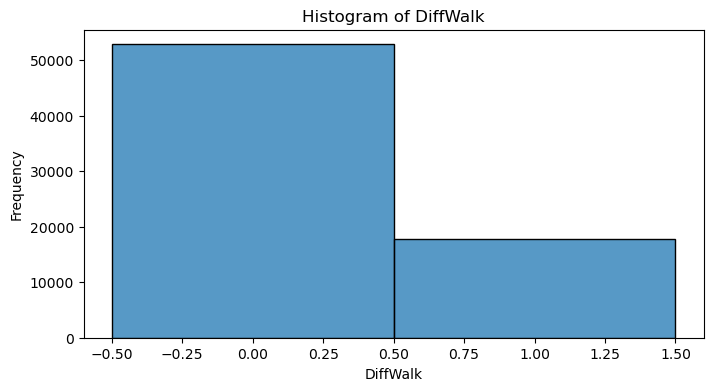

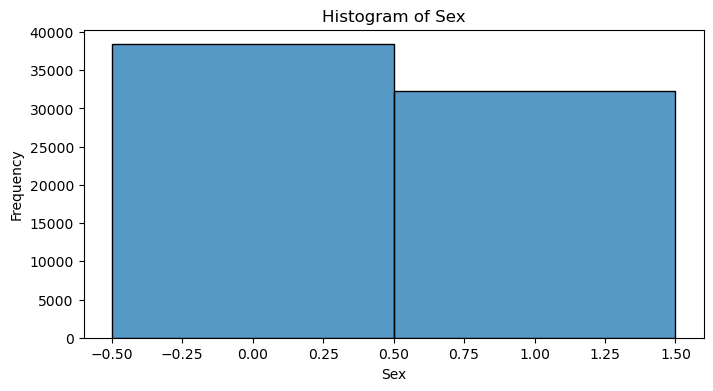

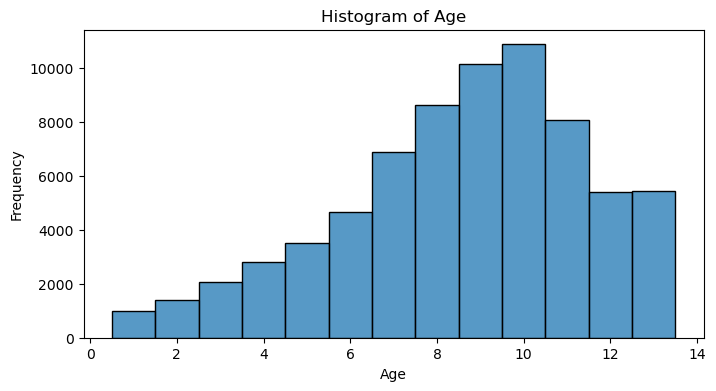

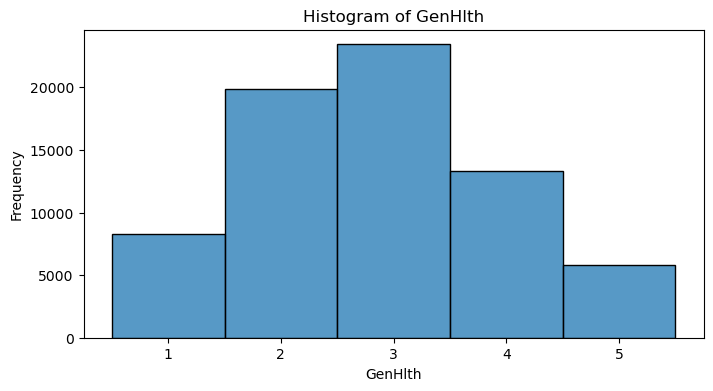

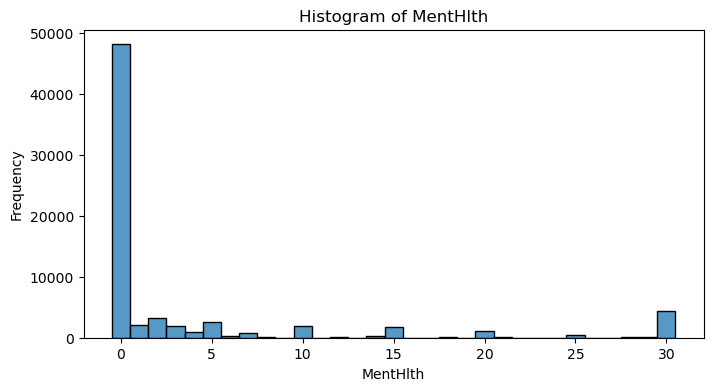

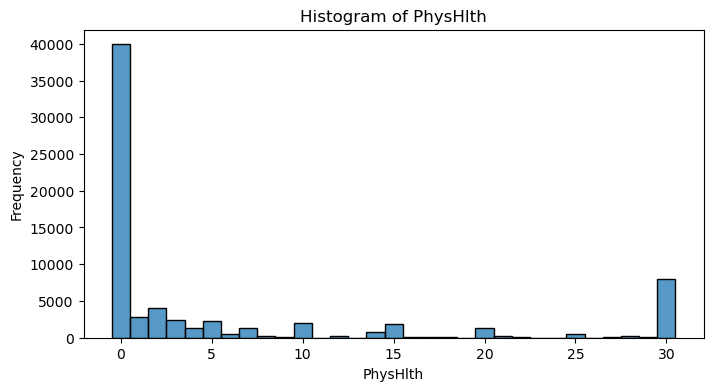

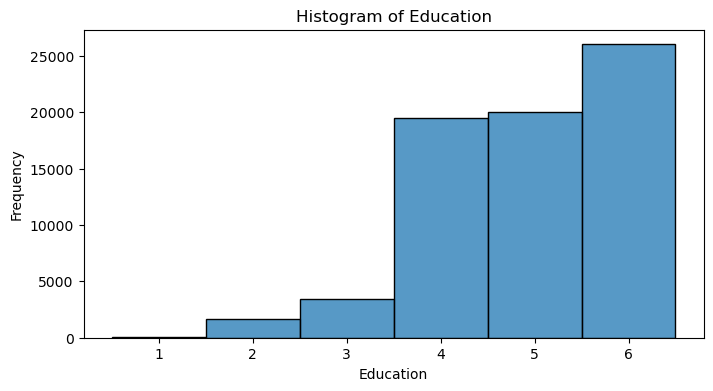

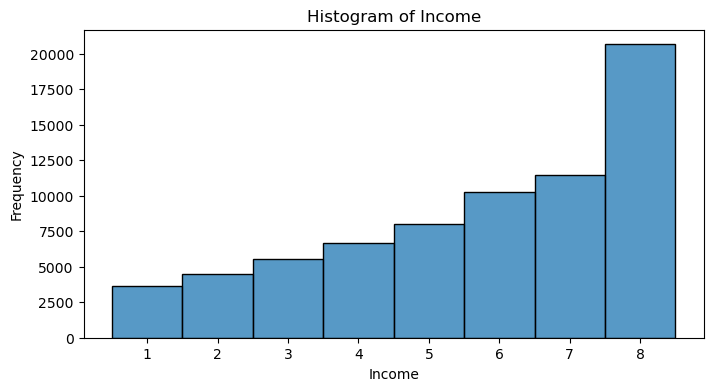

In [31]:
nominal_vars = ['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex', "Age"]

ordinal_vars = ['GenHlth', 'MentHlth', 'PhysHlth', 'Education', 'Income']

for var in nominal_vars:
    plt.figure(figsize=(8, 4))
    sns.histplot(df_diabetes_binary_50_50[var], kde=False, discrete=True)
    plt.title(f'Histogram of {var}')
    plt.xlabel(var)
    plt.ylabel('Frequency')
    plt.show()

for var in ordinal_vars:
    plt.figure(figsize=(8, 4))
    sns.histplot(df_diabetes_binary_50_50[var], kde=False, discrete=True)
    plt.title(f'Histogram of {var}')
    plt.xlabel(var)
    plt.ylabel('Frequency')
    plt.show()

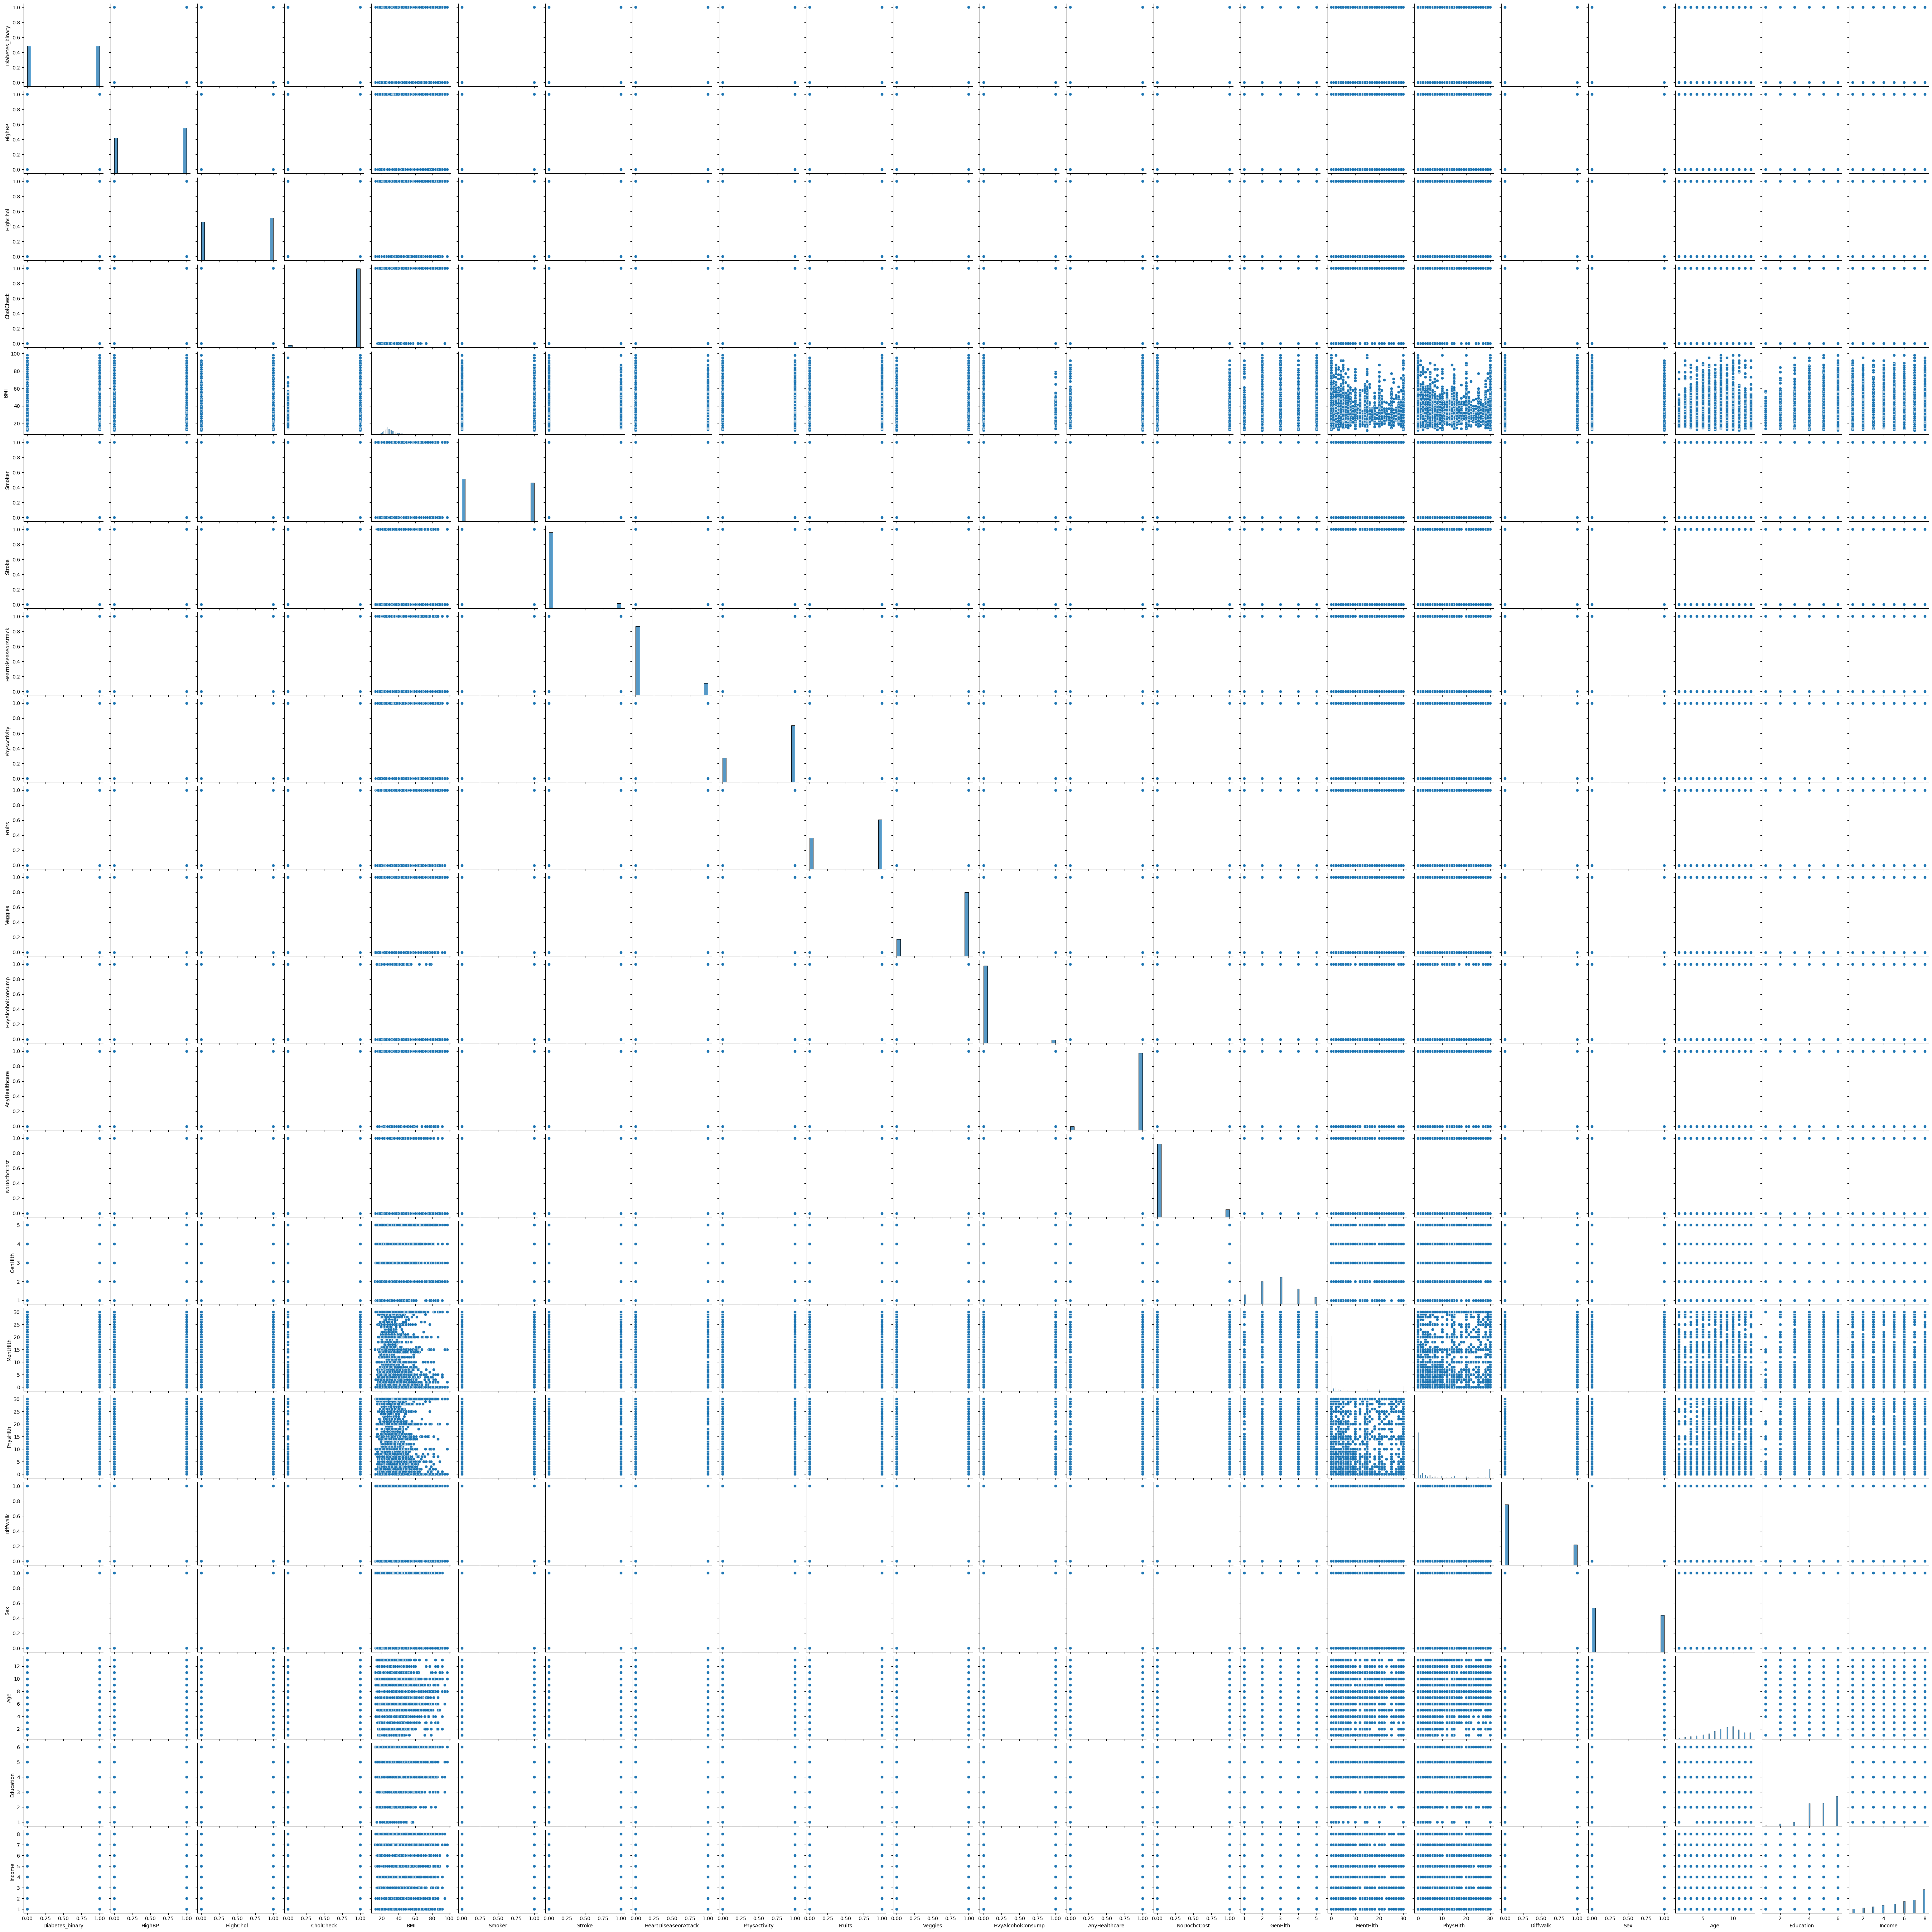

In [32]:
sns.pairplot(df_diabetes_binary_50_50)
plt.show()